In [84]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score
import matplotlib.pyplot as plt

In [85]:
# read data
raw_data = pd.read_excel("../data/default_of_credit_card_clients.xls",skiprows=[0])
raw_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [86]:
raw_data.columns

#raw_data.info

n_ones = (raw_data["default payment next month"]==1).sum()
n_zeros = (raw_data["default payment next month"]==0).sum()

print(n_ones,n_zeros)

# class imbalance

6636 23364


default payment next month
non-default    23364
default         6636
Name: count, dtype: int64


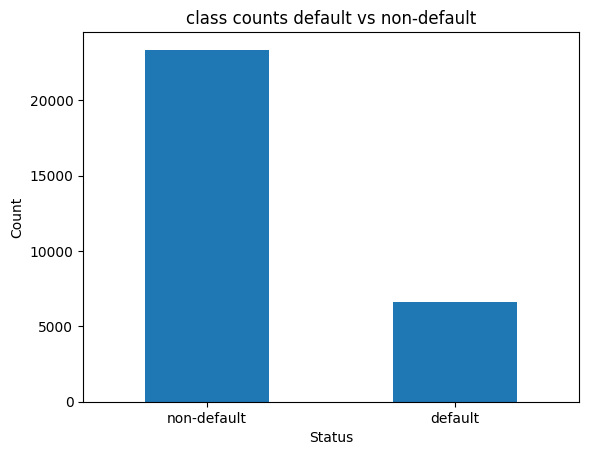

In [87]:


counts = raw_data["default payment next month"].value_counts()
counts.index = counts.index.map({0:"non-default", 1:"default"})
print(counts)
counts.plot(kind="bar",title="class counts default vs non-default")
plt.ylabel("Count")
plt.xlabel("Status")
plt.xticks(rotation=0)
plt.show()

In [88]:
# rename the target column
raw_data.rename(columns={'default payment next month':'default'},inplace=True)

# drop the ID column
#raw_data.drop('ID',axis=1, inplace=True)

# print columns after cleaning

print (raw_data.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


In [89]:
# print data overview

print (raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [90]:
#print the statistical summary

print (raw_data.describe())


                 ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_0         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -0.220667   
std        9.217904      1.123802

In [91]:
# data split and save to csv

from sklearn.model_selection import train_test_split
from pathlib import Path

target = 'default'

# first split
train, temp = train_test_split(
    raw_data,
    test_size=0.20,
    random_state=42,
    stratify=raw_data[target]
)

# second split
val, test = train_test_split(
    temp,
    test_size=0.2,
    random_state=42,
    stratify=temp[target]
)

# data directory for processed files
data_dir = Path("../data/processed")
data_dir.mkdir(parents=True,exist_ok=True)

# save to local
train.to_csv(data_dir/'train.csv',index=False)
val.to_csv(data_dir/'val.csv', index=False)
test.to_csv(data_dir/'test.csv',index=False)

print(f"Data archived in {data_dir.absolute()}")

#sanity check that files have been created


Data archived in /Users/nicholus/Documents/GitHub/credit-card-default/notebooks/../data/processed


In [92]:
# function to read the data

# read train, val test csv

train = pd.read_csv(data_dir/'train.csv')
val = pd.read_csv(data_dir/'val.csv')
test = pd.read_csv(data_dir/'test.csv')
train.head()
val.head()
test.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,10644,360000,2,3,1,38,1,2,2,0,...,21359,21581,16065,2000,0,687,3864,1065,11500,0
1,15075,50000,1,2,2,33,0,0,0,0,...,19474,19508,19837,5435,2109,1576,1000,2000,1000,0
2,12990,100000,2,2,2,36,-1,-1,-2,-2,...,-2011,1751,2238,0,0,0,3989,946,154,0
3,26420,60000,2,2,1,48,0,0,0,0,...,58124,58852,58872,2080,2530,1865,1445,293,1545,0
4,932,320000,1,1,1,60,-1,-1,-1,-1,...,886,11741,4317,3465,84440,886,11533,4317,52466,1


In [110]:
# drop the ID column, target in X_Train

# X, y
X_train = train.drop(columns=[target,'ID'])
y_train = train[target]

X_val = val.drop(columns=[target,'ID'])
y_val = val[target]

X_test = test.drop(columns=[target,'ID'])
y_test = test[target]

print(f"train {X_train.shape} val {X_val.shape} train {X_test.shape}" )


train (24000, 23) val (4800, 23) train (1200, 23)


In [114]:
# column list
column_list = X_train.columns.tolist()
column_list

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [115]:
#feature scaling 
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

array([[-0.05686623,  0.80844039,  0.18452304, ...,  0.08696116,
         0.50039738,  0.04874486],
       [-0.13408117,  0.80844039, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231],
       [-1.21509034, -1.23694958,  0.18452304, ..., -0.29855368,
        -0.29671021, -0.23696983],
       ...,
       [-0.36572599,  0.80844039, -1.07753249, ..., -0.18527633,
        -0.23723448, -0.23696983],
       [ 1.48743258, -1.23694958, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231],
       [ 1.02414294, -1.23694958, -1.07753249, ..., -0.3180751 ,
        -0.31697847, -0.29299231]])

In [24]:
# baseline model: logistic regression

# Train the model

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)



LogisticRegression(max_iter=1000)

In [26]:
# prediction 
y_pred = model.predict(X_test)

In [27]:
y_test.shape

(1200,)

In [28]:
y_pred.shape

(1200,)

In [29]:
# confusion matrix

print (confusion_matrix(y_test,y_pred))

[[902  33]
 [202  63]]


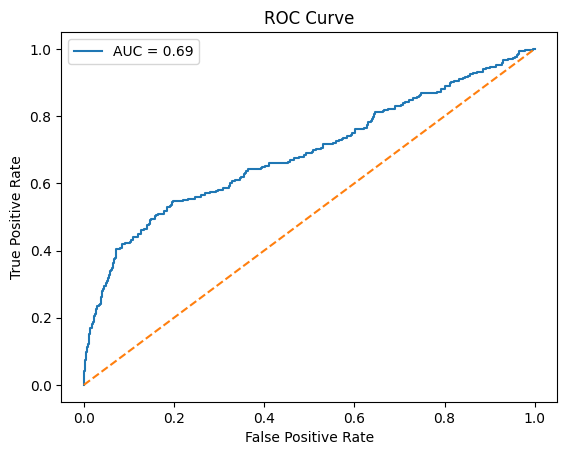

In [30]:
#ROC
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [95]:
# hyperparameter tuning : logistic regression
import numpy as np

param_grid = [
    
    {'penalty':['l1','l2'],
    'C' : np.logspace(-4,4,20),
    'solver': ['liblinear'],
    'max_iter'  : [100,1000,2500,5000]},

    {'penalty':[None],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs'],
    'max_iter'  : [100,1000,2500,5000]},

    
]


In [96]:
#get the best possible combination of hyperparameters

from sklearn.model_selection import GridSearchCV

model = LogisticRegression(random_state=42)
clf = GridSearchCV(model,param_grid=param_grid,cv=3, verbose=True)
clf

GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42),
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844...
                         {'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': [None], 'solver': ['lbfgs']}],
             verbose=True)

In [97]:
clf

GridSearchCV(cv=3, estimator=LogisticRegression(random_state=42),
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844...
                         {'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': [None], 'solver': ['lbfgs']}],
             verbose=True)

In [98]:
# apply best parameters to Logistic regression
best_clf = clf.fit(X_train,y_train)
best_clf.best_estimator_

Fitting 3 folds for each of 240 candidates, totalling 720 fits


/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-package

LogisticRegression(C=np.float64(4.281332398719396), random_state=42,
                   solver='liblinear')

In [99]:
best_clf.best_estimator_

LogisticRegression(C=np.float64(4.281332398719396), random_state=42,
                   solver='liblinear')

In [100]:
print(f'accuracy - : {best_clf.score(X_train,y_train):.3f}')

# testing 
# prediction 
y_pred = best_clf.predict(X_test)

# Evaluation 
# Classificatiion
print(classification_report(y_test,y_pred))



accuracy - : 0.811
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       935
           1       0.66      0.24      0.35       265

    accuracy                           0.80      1200
   macro avg       0.74      0.60      0.62      1200
weighted avg       0.78      0.80      0.77      1200



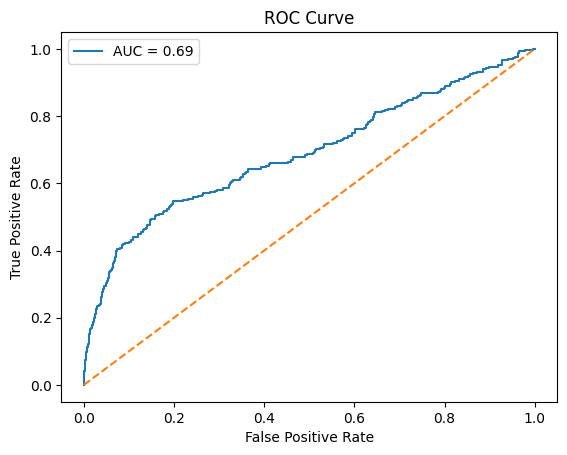

In [103]:
#ROC
y_prob = best_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

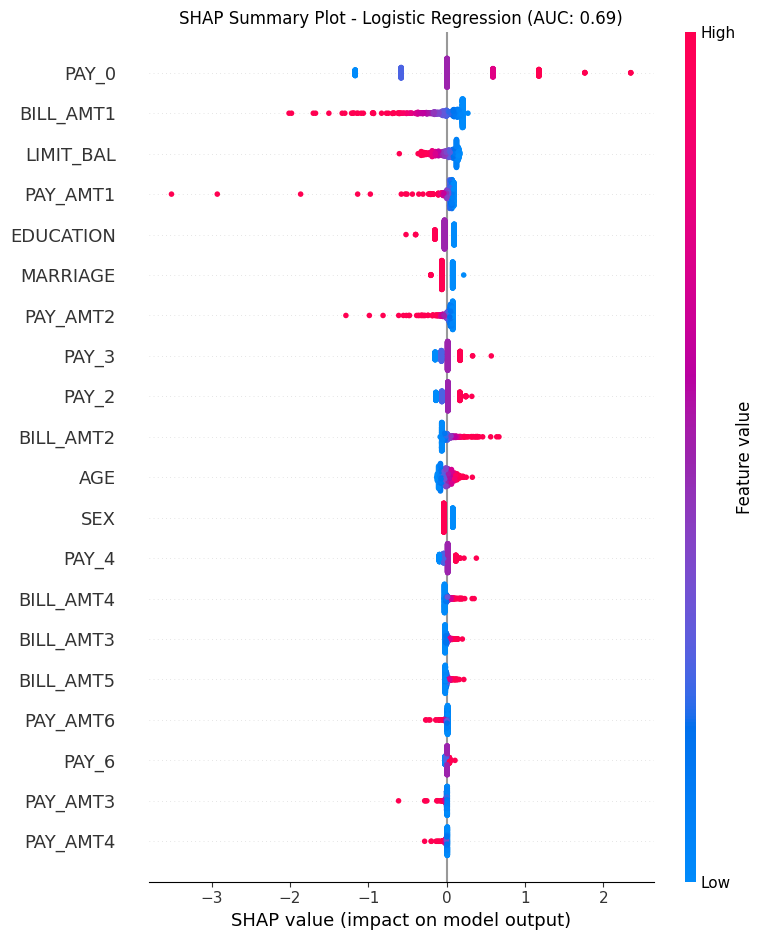

In [116]:
# Logistic Regression feature importance

import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
# We use the model and the training data to establish a "baseline"
log_reg_model = LogisticRegression(C=4.28,solver='liblinear',random_state=42)
log_reg_model.fit(X_train,y_train)


X_test_df = pd.DataFrame(X_test,columns=column_list)
explainer = shap.LinearExplainer(log_reg_model, X_train)

# 2. Calculate SHAP values for the Validation or Test set
# (Calculating on 500-1000 samples is usually enough for a clear picture)
shap_values = explainer.shap_values(X_test_df[:500])

# 3. Summary Plot
# This shows the distribution of the impact each feature has on the output
plt.title("SHAP Summary Plot - Logistic Regression (AUC: 0.69)")
shap.summary_plot(shap_values, X_test_df[:500],feature_names=column_list)



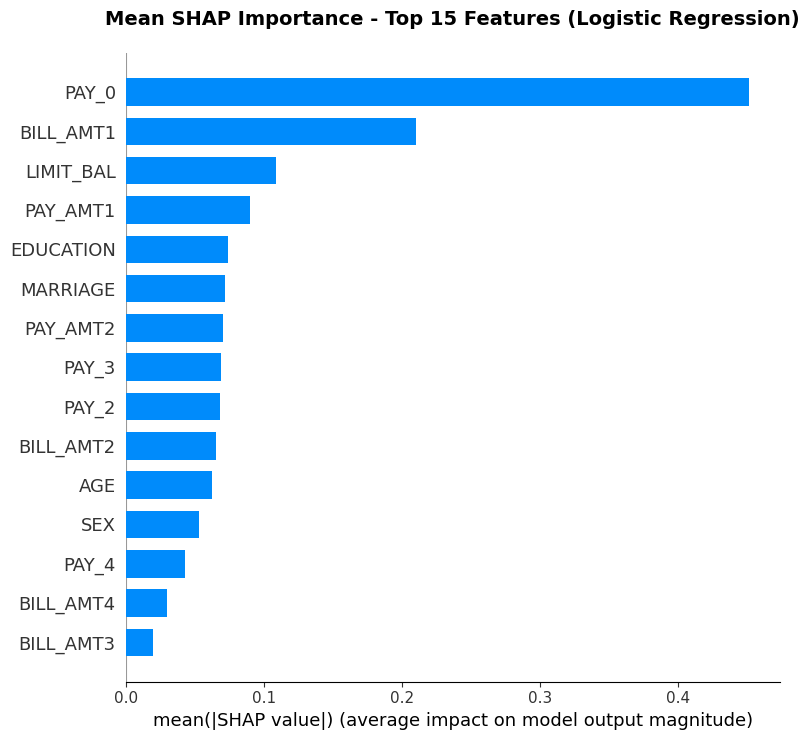

In [ ]:
# bar
import shap
import matplotlib.pyplot as plt

# 1. Ensure shap_values is in the right format for the bar plot
# For some versions of SHAP/sklearn, it returns a list. We want the positive class.
if isinstance(shap_values, list):
    plot_data = shap_values[1]
else:
    plot_data = shap_values

# 2. Generate the Bar Plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    plot_data, 
    X_test, 
    feature_names=X_test_df.columns, 
    plot_type="bar", 
    max_display=15, 
    show=False
)

# 3. Style and Title
plt.title('Mean SHAP Importance - Top 15 Features (Logistic Regression)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('mean(SHAP value) (average impact on model output magnitude)')

plt.tight_layout()
plt.show()

In [69]:
# feature engineering

def extract_features(raw_data):

    # 1. Payment-to-Bill Ratios (CRUCIAL - captures repayment capacity)
    raw_data['pay_bill_ratio_1'] = raw_data['PAY_AMT1'] / (raw_data['BILL_AMT1'] + 1)
    raw_data['pay_bill_ratio_avg'] = raw_data[['PAY_AMT1','PAY_AMT2','PAY_AMT3']].mean(axis=1) / \
                                    raw_data[['BILL_AMT1','BILL_AMT2','BILL_AMT3']].mean(axis=1).replace(0, 1)

    # 2. Payment Delay Score (sum of delays across 6 months)
    delay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    raw_data['total_delays'] = raw_data[delay_cols].clip(lower=0).sum(axis=1)
    raw_data['recent_delays'] = raw_data[['PAY_0','PAY_2']].clip(lower=0).sum(axis=1)

    # 3. Credit Utilization (how much of limit is used)
    raw_data['utilization'] = raw_data['BILL_AMT1'] / (raw_data['LIMIT_BAL'] + 1)

    # 4. Payment Momentum (improving/worsening payments)
    raw_data['pay_trend'] = raw_data['PAY_AMT6'] - raw_data['PAY_AMT1']  # Negative = getting worse

    # 5. Demographic Risk (young males higher risk)
    raw_data['age_sex_risk'] = raw_data['AGE'] * (raw_data['SEX'] == 2)  # Males=2

    print("New features added:", ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 
                                'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk'])
        
    return raw_data

In [70]:
train_features = extract_features(train)
val_features = extract_features(val)
test_features = extract_features(test)

New features added: ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk']
New features added: ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk']
New features added: ['pay_bill_ratio_1', 'pay_bill_ratio_avg', 'total_delays', 'recent_delays', 'utilization', 'pay_trend', 'age_sex_risk']


In [71]:
train_features.head

<bound method NDFrame.head of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0      22789     160000    2          2         2   33      2      2      3   
1      29007     150000    2          1         2   34      1     -1     -1   
2      16951      10000    1          2         1   50      1      2      0   
3      22281     220000    2          1         2   29      0      0      0   
4      11347     310000    2          1         2   32      1     -2     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
23995  23480     100000    2          2         2   31      0      0      0   
23996  13922     120000    2          2         2   24      0      0      0   
23997   3795     120000    2          1         2   24      0      0      0   
23998  27566     360000    1          1         1   57      1     -2     -1   
23999  27127     300000    1          1         1   35     -1     -1     -1   

       PAY_4  ...  PA

In [72]:
# drop the ID column, target in X_Train

# X, y
X_train = train_features.drop(columns=[target,'ID'])
y_train = train_features[target]

X_val = val_features.drop(columns=[target,'ID'])
y_val = val_features[target]

X_test = test_features.drop(columns=[target,'ID'])
y_test = test_features[target]


In [ ]:

# Check where the infs are
print("Inf in X_train:", np.isinf(X_train).sum().sum())
print("Inf in X_test:",  np.isinf(X_test).sum().sum())

# Replace inf with NaN, then fill with column median
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)  # Use TRAIN medians on test — no leakage

Inf in X_train: 4
Inf in X_test: 2


In [74]:
# xgboost base model
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

base_model = XGBClassifier(scale_pos_weight=23364/6636, random_state=42, n_jobs=1)

param_dist = {
    'n_estimators': [500, 800],
    'learning_rate': [0.08, 0.1],
    'max_depth': [6, 8],
    'min_child_weight': [1, 2],
    'subsample': [0.9, 1.0]
}

search = RandomizedSearchCV(base_model, param_dist, n_iter=20, scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=1)

search.fit(X_train, y_train)
test_auc = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:,1])
print("With new features - Test AUC:", test_auc)



With new features - Test AUC: 0.7655372818080921


In [75]:
search.best_params_

{'subsample': 1.0,
 'n_estimators': 500,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.08}

In [76]:
# winning model
final_model = XGBClassifier(
    subsample=1.0, n_estimators=500, min_child_weight=1, 
    max_depth=6, learning_rate=0.08, colsample_bytree=1.0,
    scale_pos_weight=23364/6636,
    tree_method='exact', n_jobs=1, random_state=42
)

In [77]:
final_model.fit(X_train,y_train)
test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:,1])

In [78]:
print(test_auc)

0.7625305216426194


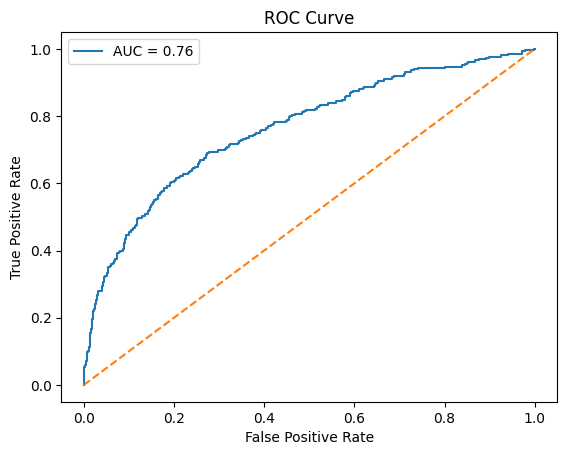

In [79]:
#ROC
y_prob = final_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr,tpr, label = "AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

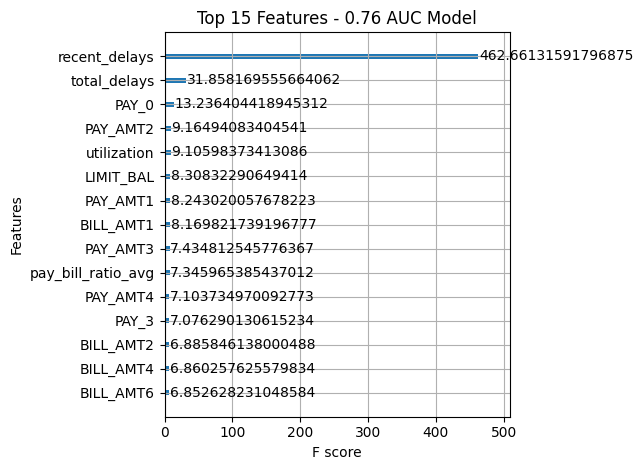

In [80]:
# shap feature importance plots
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Your trained model (the 0.76 one)
plot_importance(final_model, max_num_features=15, importance_type='gain')
plt.title('Top 15 Features - 0.76 AUC Model')
plt.tight_layout()
plt.show()

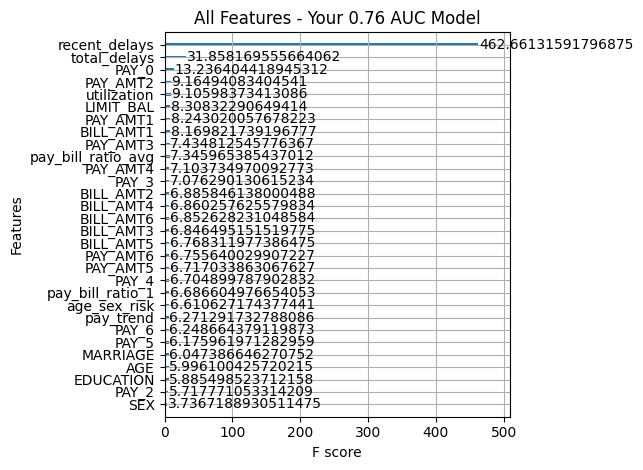

In [81]:
#all features
# final xgboost model
plot_importance(final_model, importance_type='gain')
plt.title('All Features - Your 0.76 AUC Model')
plt.tight_layout()
plt.show()

/Users/nicholus/Documents/GitHub/credit-card-default/card_default/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


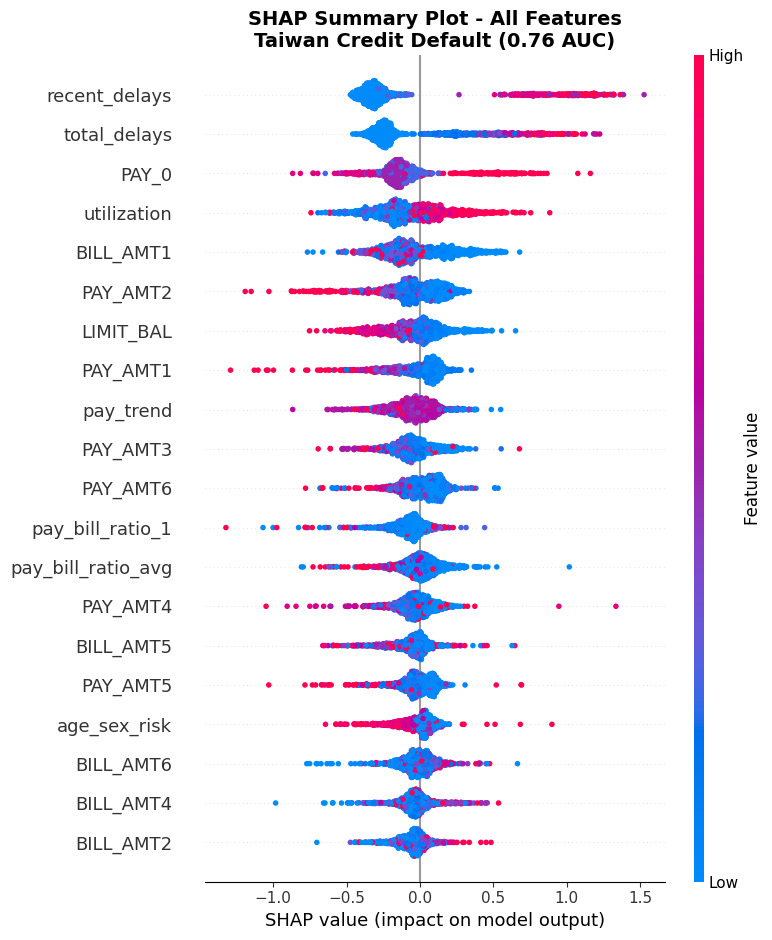

In [82]:
# SHAP
import shap

# Trained model (0.76 AUC )
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)  # Positive class only for binary

# 1. SUMMARY PLOT - ALL FEATURES (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False, max_display=20)
plt.title('SHAP Summary Plot - All Features\nTaiwan Credit Default (0.76 AUC)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

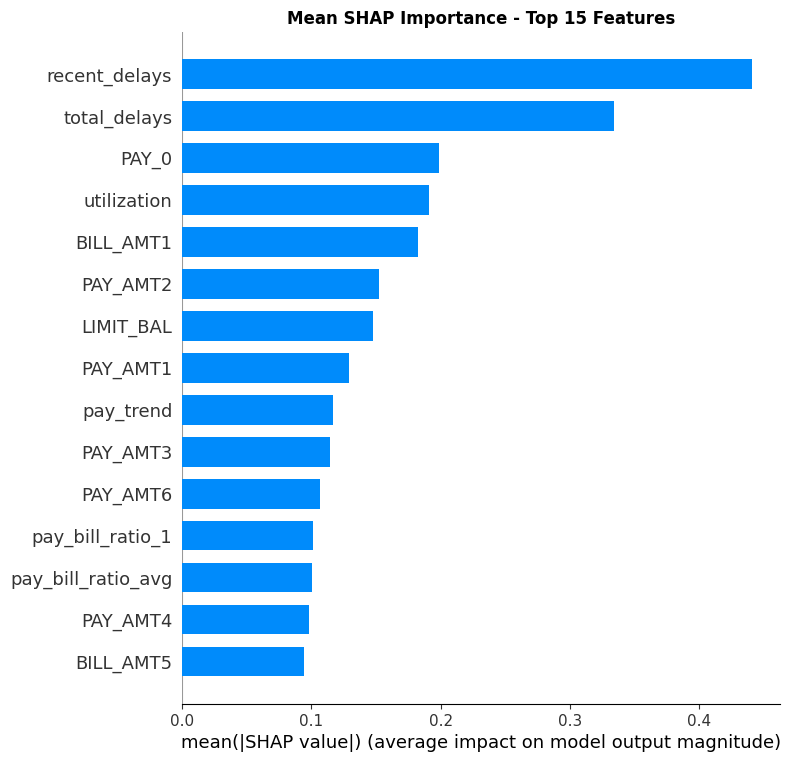

In [83]:
# bar plot

# Mean absolute SHAP values = true feature importance
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, 
                  plot_type="bar", max_display=15, show=False)
plt.title('Mean SHAP Importance - Top 15 Features', fontweight='bold')
plt.show()

In [ ]:
# save files
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.close()

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.close()